# Q-Med Colcabamba - Fase 3: fuente logística y simulación de demanda [TAYACAJA + OSRM]

> **VERSIÓN CORREGIDA:** la fuente es el almacén farmacéutico de Pampas–Tayacaja y la matriz de costo se calcula por carretera con OSRM.

**Objetivo:** incorporar una fuente farmacéutica documentada a las siete IPRESS y construir la instancia logística con distancias y tiempos por carretera.

La red modelada es:

`Almacén Especializado de Medicamentos de la RIS Tayacaja (Pampas) → 7 IPRESS de la Microrred Colcabamba`

- El almacén es el único origen `DC00` y tiene demanda cero.
- La demanda de las IPRESS es sintética y reproducible.
- El abastecimiento anterior a Pampas queda fuera del problema.

> **Precisión documental:** el POI Inicial 2024 describe la gestión DEMID/SISMED, pero no demuestra que todos los envíos lleguen directamente desde Lima. Por ello, el notebook no presenta el tramo `Lima → Pampas` como un hecho verificado.

## Evidencia y archivos

La elección del origen se apoya en:

1. [RDR 0269-2023-GOB.REG-HVCA-DIRESA](https://www.gob.pe/institucion/regionhuancavelica-diresa/normas-legales/4133044-0269-2023-gob-reg-hvca-diresa): autoriza al Sub Almacén de Medicamentos de la Red de Salud Tayacaja, en Jr. Grau 327, Pampas, para **almacenamiento y distribución**.
2. [RDR 0126-2026-GOB-REG-HVCA-DIRESA](https://www.gob.pe/institucion/regionhuancavelica-diresa/normas-legales/7993145-rdr0126-2026-gob-reg-hvca-diresa): confirma la misma dirección y su nombre actual, Almacén Especializado de Medicamentos de la RIS Tayacaja.
3. [POI Inicial 2024 de DIRESA Huancavelica](https://diresahuancavelica.gob.pe/archivos/transparencia/POI/POI%20INICIAL%202024.pdf), p. 31: aporta el contexto regional de DEMID, SISMED y buenas prácticas de almacenamiento y distribución, pero no identifica el tramo desde Lima.

| Tipo | Archivo | Propósito |
|---|---|---|
| Entrada | `data/optimization/nodes.csv` | Siete IPRESS de la Fase 2 |
| Salida principal | `data/optimization/distance_matrix_with_source.csv` | Matriz vial dirigida de 8 x 8 |
| Salida | `data/optimization/duration_matrix_with_source.csv` | Tiempos estimados en minutos |
| Control | `data/optimization/distance_matrix_geodesic_with_source.csv` | Haversine |
| Salida final | `data/optimization/optimization_instance.csv` | Roles, coordenadas y demanda |

In [1]:
from __future__ import annotations

import html
import json
import os
from pathlib import Path
from urllib.request import Request, urlopen

os.environ.setdefault("MPLCONFIGDIR", "/tmp/qmed-matplotlib")

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
plt.style.use("seaborn-v0_8-whitegrid")

COLORS = {
    "navy": "#17324D", "teal": "#0F766E", "blue": "#2563EB",
    "orange": "#EA580C", "red": "#B91C1C", "purple": "#7C3AED",
    "slate": "#64748B", "light": "#E2E8F0",
}
CATEGORY_COLORS = {
    "I-1": COLORS["teal"],
    "I-2": COLORS["orange"],
    "I-4": COLORS["purple"],
}
SCENARIO_COLORS = {
    "NORMAL": COLORS["teal"],
    "TENSION": COLORS["orange"],
    "CRITICO": COLORS["red"],
}

mkdir -p failed for path O:\tmp\qmed-matplotlib: [WinError 2] El sistema no puede encontrar el archivo especificado: 'O:\\tmp'
Matplotlib created a temporary cache directory at C:\Users\guill\AppData\Local\Temp\matplotlib-wnawz68s because there was an issue with the default path (O:\tmp\qmed-matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
def locate_repo_root(start: Path | None = None) -> Path:
    configured_root = os.getenv("QMED_REPO_ROOT")
    if configured_root:
        root = Path(configured_root).expanduser().resolve()
        if not (root / "data").exists():
            raise FileNotFoundError(f"QMED_REPO_ROOT={root} no contiene data/.")
        return root
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("No se encontró la raíz del repositorio.")


REPO_ROOT = locate_repo_root()
NODES_PATH = REPO_ROOT / "data" / "optimization" / "nodes.csv"
OPTIMIZATION_DIR = REPO_ROOT / "data" / "optimization"
SIMULATED_DIR = REPO_ROOT / "data" / "simulated"
FIGURES_DIR = REPO_ROOT / "outputs" / "figures"
MAPS_DIR = REPO_ROOT / "outputs" / "maps"
for directory in [OPTIMIZATION_DIR, SIMULATED_DIR, FIGURES_DIR, MAPS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

OSRM_BASE_URL = "https://router.project-osrm.org"
OSRM_PROFILE = "driving"
EARTH_RADIUS_KM = 6371.0088
MAX_SNAP_DISTANCE_M = 250.0

## 1. Parámetros auditables

La resolución fija la dirección, pero no publica coordenadas. Se usa un punto geocodificado a nivel de calle sobre Jr. Grau, Pampas; por ello, la posición es aproximada y se declara como tal. El error de una cuadra es pequeño frente a recorridos de decenas de kilómetros, pero no debe confundirse con una coordenada catastral.

In [3]:
SOURCE_NODE = {
    "NODE_ID": "DC00",
    "NODE_NAME": "ALMACÉN ESPECIALIZADO DE MEDICAMENTOS DE LA RIS TAYACAJA",
    "ADDRESS": "Jr. Grau N.° 327, Pampas, Tayacaja, Huancavelica",
    "LATITUDE": -12.39986237,
    "LONGITUDE": -74.87108715,
    "COORDINATE_QUALITY": "Aproximación a nivel de calle; no coordenada predial",
    "SOURCE_REFERENCE": (
        "RDR 0269-2023-GOB.REG-HVCA-DIRESA y "
        "RDR 0126-2026-GOB-REG-HVCA-DIRESA"
    ),
}

EXPECTED_DESTINATIONS = 7
RANDOM_SEED = 20260723
N_SIMULATIONS = 1_000
TOTAL_BASE_DEMAND = 120
CATEGORY_WEIGHTS = {"I-1": 1.00, "I-2": 1.35, "I-4": 1.80}
SCENARIOS = {
    "NORMAL": {"EXTRA_RATE": 0.10, "LABEL": "Normal"},
    "TENSION": {"EXTRA_RATE": 0.35, "LABEL": "Tensión"},
    "CRITICO": {"EXTRA_RATE": 0.70, "LABEL": "Crítico"},
}
SELECTED_SCENARIO = "TENSION"
SELECTED_QUANTILE = 0.90

assert SELECTED_SCENARIO in SCENARIOS
assert 0 < SELECTED_QUANTILE < 1
assert N_SIMULATIONS >= 100

parameter_table = pd.DataFrame(
    [
        {"PARÁMETRO": "Nodo fuente", "VALOR": SOURCE_NODE["NODE_NAME"]},
        {"PARÁMETRO": "Dirección oficial", "VALOR": SOURCE_NODE["ADDRESS"]},
        {
            "PARÁMETRO": "Coordenadas usadas",
            "VALOR": (
                f"{SOURCE_NODE['LATITUDE']}, {SOURCE_NODE['LONGITUDE']}"
            ),
        },
        {
            "PARÁMETRO": "Calidad de coordenada",
            "VALOR": SOURCE_NODE["COORDINATE_QUALITY"],
        },
        {
            "PARÁMETRO": "Métrica logística principal",
            "VALOR": "Distancia por carretera (OSRM / OpenStreetMap)",
        },
        {
            "PARÁMETRO": "Matriz para optimización",
            "VALOR": "distance_matrix_with_source.csv",
        },
        {"PARÁMETRO": "Destinos", "VALOR": EXPECTED_DESTINATIONS},
        {"PARÁMETRO": "Demanda base total", "VALOR": TOTAL_BASE_DEMAND},
        {"PARÁMETRO": "Simulaciones", "VALOR": N_SIMULATIONS},
        {"PARÁMETRO": "Semilla", "VALOR": RANDOM_SEED},
        {"PARÁMETRO": "Escenario elegido", "VALOR": SELECTED_SCENARIO},
        {"PARÁMETRO": "Cuantil", "VALOR": SELECTED_QUANTILE},
    ]
)
display(parameter_table)

,PARÁMETRO,VALOR
0,Nodo fuente,ALMACÉN ESPECIALIZADO DE MEDICAMENTOS DE LA RI...
1,Dirección oficial,"Jr. Grau N.° 327, Pampas, Tayacaja, Huancavelica"
2,Coordenadas usadas,"-12.39986237, -74.87108715"
3,Calidad de coordenada,Aproximación a nivel de calle; no coordenada p...
4,Métrica logística principal,Distancia por carretera (OSRM / OpenStreetMap)
5,Matriz para optimización,distance_matrix_with_source.csv
6,Destinos,7
7,Demanda base total,120
8,Simulaciones,1000
9,Semilla,20260723


## 2. Construcción de la red logística

Las siete IPRESS permanecen como destinos. `DC00` es un establecimiento farmacéutico externo a RENIPRESS y se agrega con rol `SOURCE`.

In [4]:
REQUIRED_NODE_COLUMNS = {
    "NODE_ID", "COD_IPRESS", "NOMBRE", "CATEGORIA", "LATITUD", "LONGITUD",
}
if not NODES_PATH.exists():
    raise FileNotFoundError(
        f"No existe {NODES_PATH}. Ejecuta primero la Fase 2 corregida."
    )

destinations = pd.read_csv(
    NODES_PATH, encoding="utf-8-sig", dtype={"COD_IPRESS": "string"}
)
missing = REQUIRED_NODE_COLUMNS.difference(destinations.columns)
if missing:
    raise ValueError("Faltan columnas: " + ", ".join(sorted(missing)))
if len(destinations) != EXPECTED_DESTINATIONS:
    raise ValueError(
        f"Se esperaban {EXPECTED_DESTINATIONS} destinos; hay {len(destinations)}."
    )
if destinations["NODE_ID"].duplicated().any():
    raise ValueError("NODE_ID debe ser único.")

for column in ["LATITUD", "LONGITUD"]:
    destinations[column] = pd.to_numeric(destinations[column], errors="coerce")
if destinations[["LATITUD", "LONGITUD"]].isna().any().any():
    raise ValueError("Todos los destinos deben tener coordenadas.")

destinations = destinations.sort_values("NODE_ID", kind="stable").copy()
destinations["ROLE"] = "DESTINATION"
destinations["NODE_INDEX"] = np.arange(1, len(destinations) + 1)
destinations["SOURCE_REFERENCE"] = ""
destinations["ADDRESS"] = ""
destinations["COORDINATE_QUALITY"] = "RENIPRESS"

source_row = {
    "NODE_ID": SOURCE_NODE["NODE_ID"],
    "NODE_ORDER": -1,
    "COD_IPRESS": "",
    "NOMBRE": SOURCE_NODE["NODE_NAME"],
    "CATEGORIA": "CENTRO LOGÍSTICO",
    "LATITUD": SOURCE_NODE["LATITUDE"],
    "LONGITUD": SOURCE_NODE["LONGITUDE"],
    "INSTITUCION": "UNIDAD EJECUTORA 403 RED DE SALUD TAYACAJA",
    "TIPO_ESTABLECIMIENTO": "ALMACÉN FARMACÉUTICO",
    "RED": "RIS TAYACAJA",
    "MICRORED": "NO APLICA",
    "ROLE": "SOURCE",
    "NODE_INDEX": 0,
    "SOURCE_REFERENCE": SOURCE_NODE["SOURCE_REFERENCE"],
    "ADDRESS": SOURCE_NODE["ADDRESS"],
    "COORDINATE_QUALITY": SOURCE_NODE["COORDINATE_QUALITY"],
}
missing_source_fields = set(destinations.columns).difference(source_row)
if missing_source_fields:
    raise ValueError(
        "La fuente no define: " + ", ".join(sorted(missing_source_fields))
    )

network_nodes = pd.concat(
    [pd.DataFrame([source_row]), destinations], ignore_index=True
).sort_values("NODE_INDEX", kind="stable").reset_index(drop=True)
display(
    network_nodes[
        [
            "NODE_INDEX", "NODE_ID", "NOMBRE", "ROLE",
            "LATITUD", "LONGITUD", "COORDINATE_QUALITY",
        ]
    ]
)

,NODE_INDEX,NODE_ID,NOMBRE,ROLE,LATITUD,LONGITUD,COORDINATE_QUALITY
0,0,DC00,ALMACÉN ESPECIALIZADO DE MEDICAMENTOS DE LA RI...,SOURCE,-12.400,-74.871,Aproximación a nivel de calle; no coordenada p...
1,1,IP01,COLCABAMBA,DESTINATION,-12.408,-74.681,RENIPRESS
2,2,IP02,CARPAPATA,DESTINATION,-12.388,-74.750,RENIPRESS
3,3,IP03,POCCYACC,DESTINATION,-12.478,-74.650,RENIPRESS
4,4,IP04,OCORO,DESTINATION,-12.350,-74.728,RENIPRESS
5,5,IP05,TOCAS,DESTINATION,-12.443,-74.653,RENIPRESS
6,6,IP06,CHACHAS,DESTINATION,-12.428,-74.619,RENIPRESS
7,7,IP07,RANRA,DESTINATION,-12.341,-74.743,RENIPRESS


## 3. Matrices viales con el nodo fuente

La matriz principal usa kilómetros por carretera. OSRM también entrega duración estimada. Haversine se conserva para medir el factor de desvío, no como costo de optimización.

In [5]:
def fetch_json(url: str, timeout: int = 90) -> dict:
    request = Request(
        url,
        headers={"User-Agent": "QMed-Colcabamba-Hackathon/1.0"},
    )
    with urlopen(request, timeout=timeout) as response:
        return json.load(response)


def haversine_matrix(
    latitudes: np.ndarray,
    longitudes: np.ndarray,
    radius_km: float = EARTH_RADIUS_KM,
) -> np.ndarray:
    lat = np.radians(np.asarray(latitudes, dtype=float))
    lon = np.radians(np.asarray(longitudes, dtype=float))
    delta_lat = lat[:, None] - lat[None, :]
    delta_lon = lon[:, None] - lon[None, :]
    a = (
        np.sin(delta_lat / 2.0) ** 2
        + np.cos(lat[:, None])
        * np.cos(lat[None, :])
        * np.sin(delta_lon / 2.0) ** 2
    )
    a = np.clip(a, 0.0, 1.0)
    result = 2.0 * radius_km * np.arcsin(np.sqrt(a))
    np.fill_diagonal(result, 0.0)
    return result


def osrm_table(node_frame: pd.DataFrame) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    coordinates = ";".join(
        f"{row.LONGITUD:.8f},{row.LATITUD:.8f}"
        for row in node_frame.itertuples(index=False)
    )
    url = (
        f"{OSRM_BASE_URL}/table/v1/{OSRM_PROFILE}/{coordinates}"
        "?annotations=distance,duration"
    )
    payload = fetch_json(url)
    if payload.get("code") != "Ok":
        raise RuntimeError(f"OSRM no devolvió una tabla válida: {payload}")
    if any(value is None for row in payload["distances"] for value in row):
        raise RuntimeError("OSRM encontró pares sin conexión.")
    distances_km = np.asarray(payload["distances"], dtype=float) / 1000.0
    durations_min = np.asarray(payload["durations"], dtype=float) / 60.0
    snap_distances_m = np.asarray(
        [source["distance"] for source in payload["sources"]], dtype=float
    )
    return distances_km, durations_min, snap_distances_m


def osrm_route(origin: pd.Series, destination: pd.Series) -> dict:
    coordinates = (
        f"{origin['LONGITUD']:.8f},{origin['LATITUD']:.8f};"
        f"{destination['LONGITUD']:.8f},{destination['LATITUD']:.8f}"
    )
    url = (
        f"{OSRM_BASE_URL}/route/v1/{OSRM_PROFILE}/{coordinates}"
        "?overview=full&geometries=geojson&steps=false"
    )
    payload = fetch_json(url)
    if payload.get("code") != "Ok" or not payload.get("routes"):
        raise RuntimeError(f"OSRM no encontró ruta: {payload}")
    route = payload["routes"][0]
    return {
        "DISTANCE_KM": route["distance"] / 1000.0,
        "DURATION_MIN": route["duration"] / 60.0,
        "LATLON": [
            [latitude, longitude]
            for longitude, latitude in route["geometry"]["coordinates"]
        ],
    }


node_ids = network_nodes["NODE_ID"].tolist()
geodesic_values = haversine_matrix(
    network_nodes["LATITUD"].to_numpy(),
    network_nodes["LONGITUD"].to_numpy(),
)
road_distance_values, duration_values, snap_distances_m = osrm_table(
    network_nodes
)
geodesic_matrix = pd.DataFrame(
    geodesic_values, index=node_ids, columns=node_ids
)
road_distance_matrix = pd.DataFrame(
    road_distance_values, index=node_ids, columns=node_ids
)
duration_matrix = pd.DataFrame(
    duration_values, index=node_ids, columns=node_ids
)
for frame in [geodesic_matrix, road_distance_matrix, duration_matrix]:
    frame.index.name = "NODE_ID"

source = network_nodes.loc[network_nodes["ROLE"].eq("SOURCE")].iloc[0]
destination_nodes = network_nodes.loc[
    network_nodes["ROLE"].eq("DESTINATION")
].copy()
source_routes = {}
source_route_rows = []
for destination in destination_nodes.itertuples(index=False):
    destination_series = network_nodes.loc[
        network_nodes["NODE_ID"].eq(destination.NODE_ID)
    ].iloc[0]
    route = osrm_route(source, destination_series)
    source_routes[destination.NODE_ID] = route["LATLON"]
    source_route_rows.append(
        {
            "NODE_ID": destination.NODE_ID,
            "NOMBRE": destination.NOMBRE,
            "CATEGORIA": destination.CATEGORIA,
            "GEODESIC_DISTANCE_KM": geodesic_matrix.loc["DC00", destination.NODE_ID],
            "ROAD_DISTANCE_KM": road_distance_matrix.loc["DC00", destination.NODE_ID],
            "DURATION_MIN": duration_matrix.loc["DC00", destination.NODE_ID],
        }
    )
source_distances = pd.DataFrame(source_route_rows)
source_distances["DETOUR_RATIO"] = (
    source_distances["ROAD_DISTANCE_KM"]
    / source_distances["GEODESIC_DISTANCE_KM"]
)
source_distances = source_distances.sort_values("ROAD_DISTANCE_KM")

display(road_distance_matrix.round(2))
print("Costos desde DC00 por carretera")
display(source_distances.round(2))

,DC00,IP01,IP02,IP03,IP04,IP05,IP06,IP07
NODE_ID,,,,,,,,
DC00,0.000,57.500,34.690,67.690,54.540,66.250,91.690,51.990
IP01,57.500,0.000,24.420,17.580,25.740,8.990,25.490,32.110
IP02,34.690,24.420,0.000,41.760,21.470,33.180,49.670,18.910
IP03,67.690,17.580,41.760,0.000,43.080,9.170,21.440,49.450
IP04,54.540,25.740,21.470,43.080,0.000,34.500,50.990,7.260
IP05,66.250,8.990,33.180,9.170,34.500,0.000,20.900,40.870
IP06,91.690,25.490,49.670,21.440,50.990,20.900,0.000,57.360
IP07,51.990,32.110,18.910,49.450,7.260,40.870,57.360,0.000


Costos desde DC00 por carretera


,NODE_ID,NOMBRE,CATEGORIA,GEODESIC_DISTANCE_KM,ROAD_DISTANCE_KM,DURATION_MIN,DETOUR_RATIO
1,IP02,CARPAPATA,I-2,13.260,34.690,36.770,2.620
6,IP07,RANRA,I-1,15.390,51.990,57.960,3.380
3,IP04,OCORO,I-2,16.460,54.540,59.980,3.310
0,IP01,COLCABAMBA,I-4,20.640,57.500,58.550,2.790
4,IP05,TOCAS,I-2,24.190,66.250,68.350,2.740
2,IP03,POCCYACC,I-1,25.510,67.690,73.020,2.650
5,IP06,CHACHAS,I-1,27.600,91.690,96.160,3.320


## 4. Representación vial de la fuente y los destinos

Las curvas siguen las carreteras calculadas por OSRM. El gráfico derecho muestra por qué Haversine era insuficiente: en la zona andina el recorrido vial puede multiplicar varias veces la separación directa.

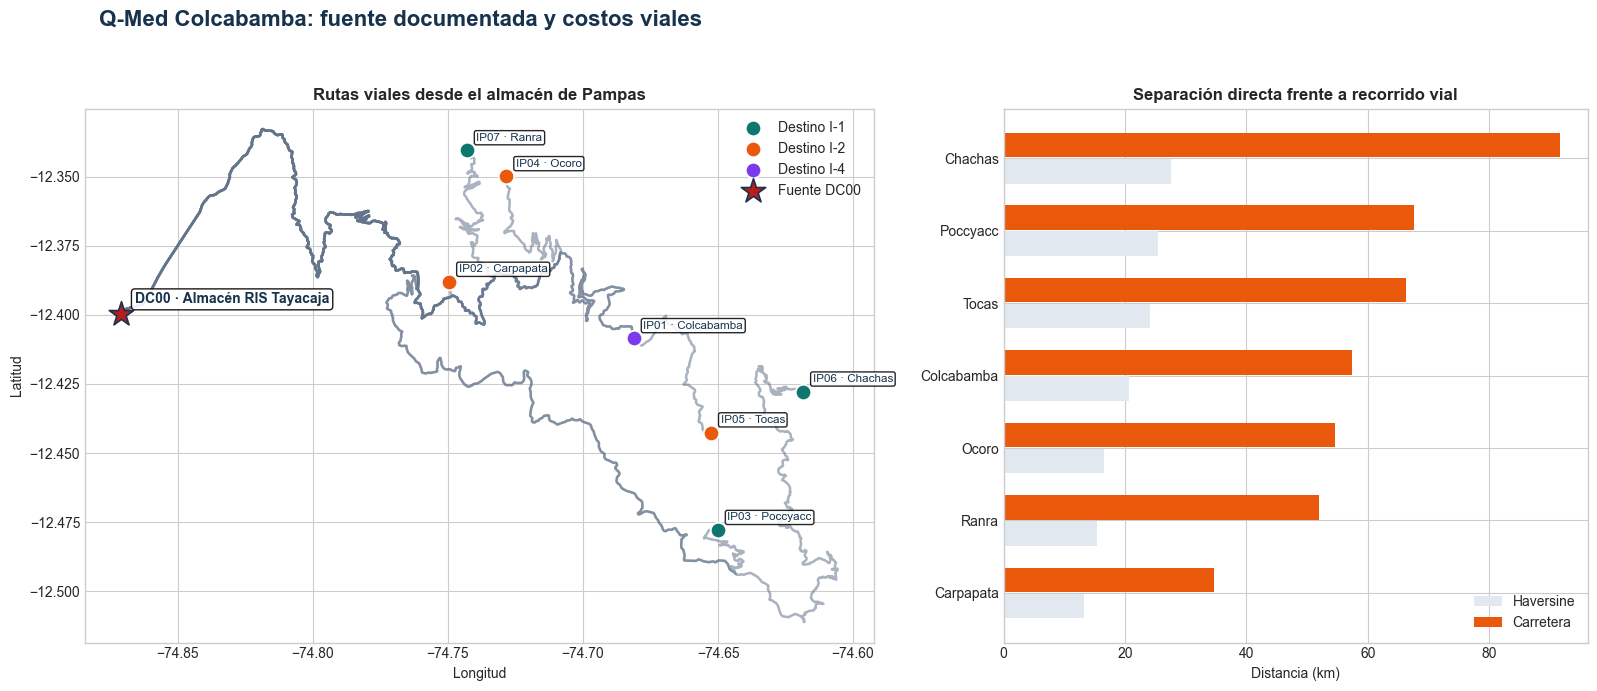

In [6]:
fig, (ax_map, ax_compare) = plt.subplots(
    1, 2, figsize=(16, 7), gridspec_kw={"width_ratios": [1.35, 1]}
)

for destination in destination_nodes.itertuples(index=False):
    route_points = np.asarray(source_routes[destination.NODE_ID])
    ax_map.plot(
        route_points[:, 1], route_points[:, 0],
        color=COLORS["slate"], linewidth=1.8, alpha=0.55, zorder=1,
    )

for category, group in destination_nodes.groupby("CATEGORIA", sort=True):
    ax_map.scatter(
        group["LONGITUD"], group["LATITUD"], s=125,
        color=CATEGORY_COLORS.get(category, COLORS["slate"]),
        edgecolor="white", linewidth=1.3, label=f"Destino {category}", zorder=3,
    )
ax_map.scatter(
    source["LONGITUD"], source["LATITUD"], s=340, marker="*",
    color=COLORS["red"], edgecolor=COLORS["navy"], linewidth=1.2,
    label="Fuente DC00", zorder=5,
)
ax_map.annotate(
    "DC00 · Almacén RIS Tayacaja",
    (source["LONGITUD"], source["LATITUD"]),
    xytext=(10, 8), textcoords="offset points",
    fontweight="bold", color=COLORS["navy"],
    bbox={"boxstyle": "round,pad=0.25", "fc": "white", "alpha": 0.9},
)
for row in destination_nodes.itertuples(index=False):
    ax_map.annotate(
        f"{row.NODE_ID} · {str(row.NOMBRE).title()}",
        (row.LONGITUD, row.LATITUD),
        xytext=(7, 7), textcoords="offset points",
        fontsize=8.4, color=COLORS["navy"],
        bbox={"boxstyle": "round,pad=0.18", "fc": "white", "alpha": 0.85},
    )
ax_map.set_title("Rutas viales desde el almacén de Pampas", fontweight="bold")
ax_map.set_xlabel("Longitud")
ax_map.set_ylabel("Latitud")
ax_map.legend(frameon=False, loc="best")
ax_map.set_aspect(
    1 / np.cos(np.radians(network_nodes["LATITUD"].mean())),
    adjustable="datalim",
)

comparison = source_distances.sort_values("ROAD_DISTANCE_KM")
y = np.arange(len(comparison))
ax_compare.barh(
    y - 0.18, comparison["GEODESIC_DISTANCE_KM"], height=0.34,
    color=COLORS["light"], label="Haversine",
)
ax_compare.barh(
    y + 0.18, comparison["ROAD_DISTANCE_KM"], height=0.34,
    color=COLORS["orange"], label="Carretera",
)
ax_compare.set_yticks(y, comparison["NOMBRE"].str.title())
ax_compare.set_xlabel("Distancia (km)")
ax_compare.set_title("Separación directa frente a recorrido vial", fontweight="bold")
ax_compare.legend(frameon=False)

fig.suptitle(
    "Q-Med Colcabamba: fuente documentada y costos viales",
    x=0.06, ha="left", fontsize=16, fontweight="bold", color=COLORS["navy"],
)
fig.tight_layout(rect=(0, 0, 1, 0.94))
source_map_path = FIGURES_DIR / "source_to_destinations.png"
fig.savefig(source_map_path, dpi=190, bbox_inches="tight", facecolor="white")
plt.show()

In [7]:
interactive_map_path = MAPS_DIR / "distribution_source_interactive.html"
try:
    import folium
    from folium.plugins import Fullscreen
    FOLIUM_AVAILABLE = True
except ModuleNotFoundError:
    FOLIUM_AVAILABLE = False
    print("Instala folium para generar el mapa interactivo.")

if FOLIUM_AVAILABLE:
    interactive_map = folium.Map(
        location=[
            network_nodes["LATITUD"].mean(),
            network_nodes["LONGITUD"].mean(),
        ],
        zoom_start=10,
        tiles="CartoDB positron",
        control_scale=True,
    )
    route_layer = folium.FeatureGroup(
        name="Rutas por carretera desde DC00", show=True
    )
    destination_layer = folium.FeatureGroup(name="IPRESS destino", show=True)

    source_popup = f"""
    <div style="font-family:Arial;min-width:300px;line-height:1.45">
      <b style="font-size:16px;color:#17324D">Fuente documentada</b><br>
      {html.escape(SOURCE_NODE["NODE_NAME"].title())}<br>
      <b>Dirección:</b> {html.escape(SOURCE_NODE["ADDRESS"])}<br>
      <b>Evidencia:</b> RDR 0269-2023 y RDR 0126-2026<br>
      <b>Coordenada:</b> aproximada a nivel de calle
    </div>
    """
    folium.Marker(
        location=[source["LATITUD"], source["LONGITUD"]],
        tooltip="DC00 · Almacén RIS Tayacaja",
        popup=folium.Popup(source_popup, max_width=390),
        icon=folium.Icon(color="darkred", icon="home"),
    ).add_to(interactive_map)

    source_lookup = source_distances.set_index("NODE_ID")
    folium_colors = {"I-1": "green", "I-2": "orange", "I-4": "purple"}
    for destination in destination_nodes.itertuples(index=False):
        metrics = source_lookup.loc[destination.NODE_ID]
        folium.PolyLine(
            locations=source_routes[destination.NODE_ID],
            color=COLORS["slate"], weight=2.5, opacity=0.62,
            tooltip=(
                f"{str(destination.NOMBRE).title()}: "
                f"{metrics.ROAD_DISTANCE_KM:.1f} km · "
                f"{metrics.DURATION_MIN:.0f} min"
            ),
        ).add_to(route_layer)

        popup = (
            f"<b>{html.escape(str(destination.NOMBRE).title())}</b><br>"
            f"Nodo: {destination.NODE_ID}<br>"
            f"Categoría: {html.escape(str(destination.CATEGORIA))}<br>"
            f"Carretera desde DC00: {metrics.ROAD_DISTANCE_KM:.1f} km<br>"
            f"Tiempo OSRM: {metrics.DURATION_MIN:.0f} min<br>"
            f"Haversine: {metrics.GEODESIC_DISTANCE_KM:.1f} km"
        )
        folium.CircleMarker(
            location=[destination.LATITUD, destination.LONGITUD],
            radius=8, color="white", weight=2, fill=True,
            fill_color=folium_colors.get(destination.CATEGORIA, "gray"),
            fill_opacity=0.95,
            tooltip=f"{destination.NODE_ID} · {str(destination.NOMBRE).title()}",
            popup=folium.Popup(popup, max_width=340),
        ).add_to(destination_layer)

    route_layer.add_to(interactive_map)
    destination_layer.add_to(interactive_map)
    Fullscreen(position="topright").add_to(interactive_map)
    folium.LayerControl(collapsed=False).add_to(interactive_map)
    interactive_map.fit_bounds(
        network_nodes[["LATITUD", "LONGITUD"]].values.tolist(),
        padding=(25, 25),
    )
    interactive_map.save(interactive_map_path)
    display(interactive_map)
    print(f"Mapa guardado: {interactive_map_path.relative_to(REPO_ROOT)}")

C:\Users\guill\AppData\Roaming\Python\Python312\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.1) doesn't match a supported version!
  warnings.warn(


Mapa guardado: outputs\maps\distribution_source_interactive.html


## 5. Modelo de demanda simulada

Para cada destino $i$:

$q_i=b_i+S_i$

donde $b_i$ es la demanda base semanal y $S_i$ es una necesidad adicional. En el escenario $k$:

$S_i^{(k)}\sim\operatorname{Poisson}(\alpha_k b_i)$

Las unidades son equivalentes de reposición por ciclo semanal. Los pesos por categoría son un proxy explícito, no demanda observada.

In [8]:
def integer_allocation(
    total: int,
    weights: pd.Series,
) -> pd.Series:
    if total <= 0:
        raise ValueError("El total por asignar debe ser positivo.")
    if (weights <= 0).any():
        raise ValueError("Todos los pesos deben ser positivos.")

    raw = total * weights / weights.sum()
    allocation = np.floor(raw).astype(int)
    remainder = int(total - allocation.sum())

    if remainder:
        order = (raw - allocation).sort_values(
            ascending=False,
            kind="stable",
        ).index
        allocation.loc[order[:remainder]] += 1
    return allocation


demand_basis = destination_nodes[
    ["NODE_ID", "COD_IPRESS", "NOMBRE", "CATEGORIA"]
].copy()
demand_basis["CATEGORY_WEIGHT"] = demand_basis["CATEGORIA"].map(
    CATEGORY_WEIGHTS
)
if demand_basis["CATEGORY_WEIGHT"].isna().any():
    unsupported = demand_basis.loc[
        demand_basis["CATEGORY_WEIGHT"].isna(),
        "CATEGORIA",
    ].unique()
    raise ValueError(
        "Faltan pesos para las categorías: "
        + ", ".join(map(str, unsupported))
    )

demand_basis["BASE_DEMAND"] = integer_allocation(
    TOTAL_BASE_DEMAND,
    demand_basis.set_index("NODE_ID")["CATEGORY_WEIGHT"],
).reindex(demand_basis["NODE_ID"]).to_numpy()

assert int(demand_basis["BASE_DEMAND"].sum()) == TOTAL_BASE_DEMAND
display(demand_basis)

,NODE_ID,COD_IPRESS,NOMBRE,CATEGORIA,CATEGORY_WEIGHT,BASE_DEMAND
1,IP01,00004090,COLCABAMBA,I-4,1.800,24
2,IP02,00004092,CARPAPATA,I-2,1.350,18
3,IP03,00004093,POCCYACC,I-1,1.000,14
4,IP04,00004094,OCORO,I-2,1.350,18
5,IP05,00004095,TOCAS,I-2,1.350,18
6,IP06,00007387,CHACHAS,I-1,1.000,14
7,IP07,00012900,RANRA,I-1,1.000,14


In [9]:
rng = np.random.default_rng(RANDOM_SEED)
simulation_frames = []

for scenario_name, scenario_parameters in SCENARIOS.items():
    extra_rate = scenario_parameters["EXTRA_RATE"]
    for row in demand_basis.itertuples(index=False):
        extra_demand = rng.poisson(
            lam=row.BASE_DEMAND * extra_rate,
            size=N_SIMULATIONS,
        )
        simulation_frames.append(
            pd.DataFrame(
                {
                    "SCENARIO": scenario_name,
                    "SIMULATION_ID": np.arange(
                        1,
                        N_SIMULATIONS + 1,
                        dtype=int,
                    ),
                    "NODE_ID": row.NODE_ID,
                    "NOMBRE": row.NOMBRE,
                    "CATEGORIA": row.CATEGORIA,
                    "BASE_DEMAND": row.BASE_DEMAND,
                    "EXTRA_DEMAND": extra_demand,
                    "TOTAL_DEMAND": row.BASE_DEMAND + extra_demand,
                }
            )
        )

demand_simulations = pd.concat(
    simulation_frames,
    ignore_index=True,
)

demand_summary = (
    demand_simulations.groupby(
        ["SCENARIO", "NODE_ID", "NOMBRE", "CATEGORIA"],
        as_index=False,
        sort=False,
    )
    .agg(
        BASE_DEMAND=("BASE_DEMAND", "first"),
        EXTRA_DEMAND_MEAN=("EXTRA_DEMAND", "mean"),
        DEMAND_MEAN=("TOTAL_DEMAND", "mean"),
        DEMAND_P50=("TOTAL_DEMAND", "median"),
        DEMAND_P90=(
            "TOTAL_DEMAND",
            lambda values: values.quantile(0.90),
        ),
        DEMAND_P95=(
            "TOTAL_DEMAND",
            lambda values: values.quantile(0.95),
        ),
    )
)

scenario_totals = (
    demand_simulations.groupby(
        ["SCENARIO", "SIMULATION_ID"],
        as_index=False,
    )["TOTAL_DEMAND"]
    .sum()
)
scenario_total_summary = (
    scenario_totals.groupby("SCENARIO", as_index=False)
    .agg(
        TOTAL_MEAN=("TOTAL_DEMAND", "mean"),
        TOTAL_P50=("TOTAL_DEMAND", "median"),
        TOTAL_P90=(
            "TOTAL_DEMAND",
            lambda values: values.quantile(0.90),
        ),
        TOTAL_P95=(
            "TOTAL_DEMAND",
            lambda values: values.quantile(0.95),
        ),
    )
)
scenario_total_summary["SCENARIO_ORDER"] = scenario_total_summary[
    "SCENARIO"
].map({name: order for order, name in enumerate(SCENARIOS)})
scenario_total_summary = scenario_total_summary.sort_values(
    "SCENARIO_ORDER"
).drop(columns="SCENARIO_ORDER")

print(
    f"Réplicas generadas: {len(demand_simulations):,} "
    f"({len(SCENARIOS)} escenarios × {EXPECTED_DESTINATIONS} nodos "
    f"× {N_SIMULATIONS:,} simulaciones)"
)
display(demand_summary.round(2))
print("Demanda total por escenario")
display(scenario_total_summary.round(2))

Réplicas generadas: 21,000 (3 escenarios × 7 nodos × 1,000 simulaciones)


,SCENARIO,NODE_ID,NOMBRE,CATEGORIA,BASE_DEMAND,EXTRA_DEMAND_MEAN,DEMAND_MEAN,DEMAND_P50,DEMAND_P90,DEMAND_P95
0,NORMAL,IP01,COLCABAMBA,I-4,24,2.370,26.370,26.000,28.000,29.000
1,NORMAL,IP02,CARPAPATA,I-2,18,1.810,19.810,20.000,22.000,22.000
2,NORMAL,IP03,POCCYACC,I-1,14,1.300,15.300,15.000,17.000,17.000
3,NORMAL,IP04,OCORO,I-2,18,1.820,19.820,20.000,22.000,22.000
4,NORMAL,IP05,TOCAS,I-2,18,1.870,19.870,20.000,22.000,22.000
5,NORMAL,IP06,CHACHAS,I-1,14,1.360,15.360,15.000,17.000,17.000
6,NORMAL,IP07,RANRA,I-1,14,1.370,15.370,15.000,17.000,18.000
7,TENSION,IP01,COLCABAMBA,I-4,24,8.300,32.300,32.000,36.000,37.000
8,TENSION,IP02,CARPAPATA,I-2,18,6.180,24.180,24.000,27.000,29.000
9,TENSION,IP03,POCCYACC,I-1,14,5.030,19.020,19.000,22.000,23.000


Demanda total por escenario


,SCENARIO,TOTAL_MEAN,TOTAL_P50,TOTAL_P90,TOTAL_P95
1,NORMAL,131.900,132.000,136.000,138.000
2,TENSION,161.790,162.000,170.000,173.000
0,CRITICO,204.040,204.000,216.000,219.000


## 6. Escenario robusto para optimización

Se selecciona el percentil 90 del escenario `TENSION`. El escenario y el cuantil permanecen parametrizados.

In [10]:
quantile_column = f"DEMAND_P{int(SELECTED_QUANTILE * 100):02d}"
if quantile_column not in demand_summary.columns:
    raise KeyError(
        f"El resumen no contiene el cuantil solicitado: {quantile_column}"
    )

selected_demand = demand_summary.loc[
    demand_summary["SCENARIO"].eq(SELECTED_SCENARIO),
    [
        "NODE_ID",
        "NOMBRE",
        "CATEGORIA",
        "BASE_DEMAND",
        "DEMAND_MEAN",
        quantile_column,
    ],
].copy()
selected_demand = selected_demand.rename(
    columns={quantile_column: "SELECTED_DEMAND_UNITS"}
)
selected_demand["SELECTED_DEMAND_UNITS"] = np.ceil(
    selected_demand["SELECTED_DEMAND_UNITS"]
).astype(int)
selected_demand["CONTINGENCY_UNITS"] = (
    selected_demand["SELECTED_DEMAND_UNITS"]
    - selected_demand["BASE_DEMAND"]
)
selected_demand["SELECTED_SCENARIO"] = SELECTED_SCENARIO
selected_demand["SELECTED_QUANTILE"] = SELECTED_QUANTILE

optimization_instance = network_nodes[
    [
        "NODE_INDEX",
        "NODE_ID",
        "COD_IPRESS",
        "NOMBRE",
        "CATEGORIA",
        "LATITUD",
        "LONGITUD",
        "ROLE",
    ]
].copy()
optimization_instance = optimization_instance.merge(
    selected_demand[
        ["NODE_ID", "SELECTED_DEMAND_UNITS"]
    ],
    on="NODE_ID",
    how="left",
)
optimization_instance["DEMAND_UNITS"] = (
    optimization_instance["SELECTED_DEMAND_UNITS"]
    .fillna(0)
    .astype(int)
)
optimization_instance = optimization_instance.drop(
    columns="SELECTED_DEMAND_UNITS"
)

display(selected_demand.sort_values("SELECTED_DEMAND_UNITS", ascending=False))
print(
    "Demanda total seleccionada: "
    f"{selected_demand['SELECTED_DEMAND_UNITS'].sum()} unidades equivalentes"
)

,NODE_ID,NOMBRE,CATEGORIA,BASE_DEMAND,DEMAND_MEAN,SELECTED_DEMAND_UNITS,CONTINGENCY_UNITS,SELECTED_SCENARIO,SELECTED_QUANTILE
7,IP01,COLCABAMBA,I-4,24,32.295,36,12,TENSION,0.900
11,IP05,TOCAS,I-2,18,24.279,28,10,TENSION,0.900
8,IP02,CARPAPATA,I-2,18,24.182,27,9,TENSION,0.900
10,IP04,OCORO,I-2,18,24.206,27,9,TENSION,0.900
9,IP03,POCCYACC,I-1,14,19.025,22,8,TENSION,0.900
12,IP06,CHACHAS,I-1,14,18.767,22,8,TENSION,0.900
13,IP07,RANRA,I-1,14,19.041,22,8,TENSION,0.900


Demanda total seleccionada: 184 unidades equivalentes


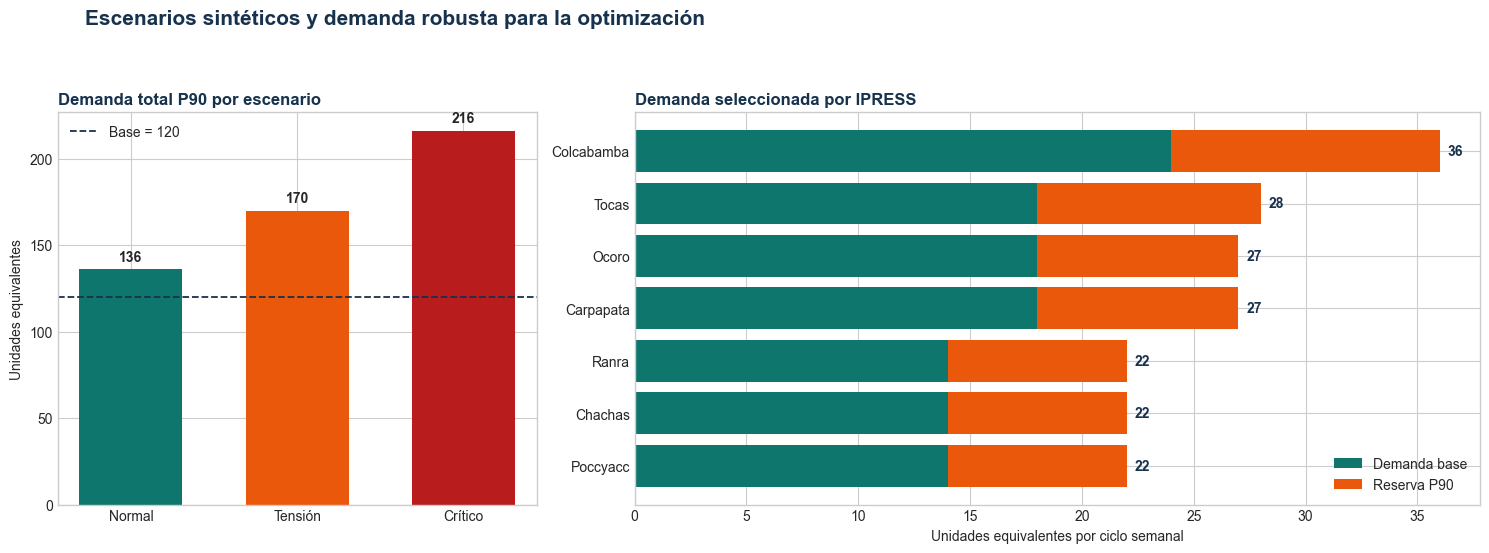

In [11]:
fig, (ax_scenarios, ax_selected) = plt.subplots(
    1,
    2,
    figsize=(15, 5.6),
    gridspec_kw={"width_ratios": [0.85, 1.5]},
)

scenario_plot = scenario_total_summary.copy()
scenario_labels = [
    SCENARIOS[name]["LABEL"] for name in scenario_plot["SCENARIO"]
]
bars = ax_scenarios.bar(
    scenario_labels,
    scenario_plot["TOTAL_P90"],
    color=[
        SCENARIO_COLORS[name] for name in scenario_plot["SCENARIO"]
    ],
    width=0.62,
)
ax_scenarios.bar_label(
    bars,
    labels=[f"{value:.0f}" for value in scenario_plot["TOTAL_P90"]],
    padding=4,
    fontweight="bold",
)
ax_scenarios.axhline(
    TOTAL_BASE_DEMAND,
    color=COLORS["navy"],
    linestyle="--",
    linewidth=1.3,
    label=f"Base = {TOTAL_BASE_DEMAND}",
)
ax_scenarios.set_title(
    "Demanda total P90 por escenario",
    loc="left",
    fontweight="bold",
    color=COLORS["navy"],
)
ax_scenarios.set_ylabel("Unidades equivalentes")
ax_scenarios.legend(frameon=False)

selected_plot = selected_demand.sort_values(
    "SELECTED_DEMAND_UNITS",
    ascending=True,
)
ax_selected.barh(
    selected_plot["NOMBRE"].str.title(),
    selected_plot["BASE_DEMAND"],
    color=COLORS["teal"],
    label="Demanda base",
)
ax_selected.barh(
    selected_plot["NOMBRE"].str.title(),
    selected_plot["CONTINGENCY_UNITS"],
    left=selected_plot["BASE_DEMAND"],
    color=COLORS["orange"],
    label="Reserva P90",
)
for position, value in enumerate(selected_plot["SELECTED_DEMAND_UNITS"]):
    ax_selected.text(
        value + 0.35,
        position,
        str(value),
        va="center",
        fontweight="bold",
        color=COLORS["navy"],
    )
ax_selected.set_title(
    "Demanda seleccionada por IPRESS",
    loc="left",
    fontweight="bold",
    color=COLORS["navy"],
)
ax_selected.set_xlabel("Unidades equivalentes por ciclo semanal")
ax_selected.legend(frameon=False, loc="lower right")

fig.suptitle(
    "Escenarios sintéticos y demanda robusta para la optimización",
    x=0.06,
    ha="left",
    fontsize=15,
    fontweight="bold",
    color=COLORS["navy"],
)
fig.tight_layout(rect=(0, 0, 1, 0.92))

demand_figure_path = FIGURES_DIR / "demand_simulation_summary.png"
fig.savefig(
    demand_figure_path,
    dpi=180,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

## 7. Exportación y controles de cierre

La optimización consumirá `distance_matrix_with_source.csv` como matriz vial dirigida. La matriz de Haversine queda separada y no debe usarse como costo logístico.

In [12]:
nodes_with_source_path = OPTIMIZATION_DIR / "nodes_with_source.csv"
distance_with_source_path = OPTIMIZATION_DIR / "distance_matrix_with_source.csv"
duration_with_source_path = OPTIMIZATION_DIR / "duration_matrix_with_source.csv"
geodesic_with_source_path = (
    OPTIMIZATION_DIR / "distance_matrix_geodesic_with_source.csv"
)
source_routes_path = OPTIMIZATION_DIR / "source_route_summary.csv"
snap_path = OPTIMIZATION_DIR / "osrm_snap_report_with_source.csv"
simulation_path = SIMULATED_DIR / "demand_simulations.csv"
summary_path = SIMULATED_DIR / "demand_scenario_summary.csv"
selected_path = SIMULATED_DIR / "demand_selected.csv"
instance_path = OPTIMIZATION_DIR / "optimization_instance.csv"

network_nodes.to_csv(nodes_with_source_path, index=False, encoding="utf-8-sig")
road_distance_matrix.to_csv(distance_with_source_path, encoding="utf-8-sig")
duration_matrix.to_csv(duration_with_source_path, encoding="utf-8-sig")
geodesic_matrix.to_csv(geodesic_with_source_path, encoding="utf-8-sig")
source_distances.to_csv(source_routes_path, index=False, encoding="utf-8-sig")
pd.DataFrame(
    {
        "NODE_ID": network_nodes["NODE_ID"],
        "NOMBRE": network_nodes["NOMBRE"],
        "OSRM_SNAP_DISTANCE_M": snap_distances_m,
    }
).to_csv(snap_path, index=False, encoding="utf-8-sig")
demand_simulations.to_csv(
    simulation_path, index=False, encoding="utf-8-sig"
)
demand_summary.to_csv(summary_path, index=False, encoding="utf-8-sig")
selected_demand.to_csv(selected_path, index=False, encoding="utf-8-sig")
optimization_instance.to_csv(instance_path, index=False, encoding="utf-8-sig")

assert len(network_nodes) == EXPECTED_DESTINATIONS + 1
assert network_nodes["ROLE"].eq("SOURCE").sum() == 1
assert network_nodes["ROLE"].eq("DESTINATION").sum() == EXPECTED_DESTINATIONS
assert network_nodes.loc[
    network_nodes["ROLE"].eq("SOURCE"), "NOMBRE"
].eq(SOURCE_NODE["NODE_NAME"]).all()
assert optimization_instance.loc[
    optimization_instance["ROLE"].eq("SOURCE"), "DEMAND_UNITS"
].eq(0).all()
assert optimization_instance.loc[
    optimization_instance["ROLE"].eq("DESTINATION"), "DEMAND_UNITS"
].gt(0).all()
assert road_distance_matrix.shape == (8, 8)
assert duration_matrix.shape == (8, 8)
assert np.allclose(np.diag(road_distance_values), 0.0)
assert np.allclose(np.diag(duration_values), 0.0)
assert (road_distance_values >= 0).all()
assert (duration_values >= 0).all()
assert snap_distances_m.max() <= MAX_SNAP_DISTANCE_M
assert (
    source_distances["ROAD_DISTANCE_KM"]
    + 0.05
    >= source_distances["GEODESIC_DISTANCE_KM"]
).all()
assert int(demand_basis["BASE_DEMAND"].sum()) == TOTAL_BASE_DEMAND

print("Controles aprobados:")
print("  • fuente: Almacén Especializado de Medicamentos RIS Tayacaja")
print(f"  • {EXPECTED_DESTINATIONS} destinos")
print("  • matriz vial dirigida 8 x 8")
print(f"  • snap máximo a la red: {snap_distances_m.max():.1f} m")
print("  • demanda cero en la fuente y positiva en los destinos")
print("  • simulación reproducible mediante semilla fija")

Controles aprobados:
  • fuente: Almacén Especializado de Medicamentos RIS Tayacaja
  • 7 destinos
  • matriz vial dirigida 8 x 8
  • snap máximo a la red: 20.4 m
  • demanda cero en la fuente y positiva en los destinos
  • simulación reproducible mediante semilla fija


## Resultado de la Fase 3

- `DC00` es el almacén farmacéutico documentado en Pampas.
- Las siete IPRESS son destinos.
- El abastecimiento anterior a Pampas no forma parte de la optimización.
- `distance_matrix_with_source.csv` contiene kilómetros por carretera.
- `duration_matrix_with_source.csv` contiene minutos estimados.
- Haversine se conserva únicamente para auditoría.
- La demanda elegida corresponde al P90 del escenario de tensión.

Los archivos principales para la siguiente fase son `optimization_instance.csv` y `distance_matrix_with_source.csv`.